In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

In [ ]:
class StochasticBiddingEnvironment:
    def __init__(self, market_prices, probabilities, seed=None):
        self.market_prices = np.array(market_prices)
        self.probabilities = np.array(probabilities)

        assert np.isclose(self.probabilities.sum(), 1.0), \
            "Probabilities must sum to 1."

        self.rng = np.random.default_rng(seed)

    def round(self):
        return self.rng.choice(self.market_prices, p=self.probabilities)

In [ ]:
def compute_outcome(bid, market_price, valuation):
    win = bid >= market_price

    if win:
        reward = valuation - bid
        cost = bid
    else:
        reward = 0.0
        cost = 0.0

    return reward, cost, win

In [ ]:
def compute_budgeted_clairvoyant(
    bids_set,
    valuation,
    market_prices,
    probabilities,
    total_budget,
    T
):
    bids_set = np.array(bids_set)
    market_prices = np.array(market_prices)
    probabilities = np.array(probabilities)

    win_probabilities = np.array([
        np.sum(probabilities[market_prices <= bid])
        for bid in bids_set
    ])

    expected_rewards = (valuation - bids_set) * win_probabilities
    expected_costs = bids_set * win_probabilities

    rho = total_budget / T

    c = -expected_rewards
    A_ub = np.array([expected_costs])
    b_ub = np.array([rho])
    A_eq = np.ones((1, len(bids_set)))
    b_eq = np.array([1.0])
    bounds = [(0.0, 1.0) for _ in bids_set]

    res = linprog(
        c=c,
        A_ub=A_ub,
        b_ub=b_ub,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )

    if not res.success:
        raise RuntimeError("Clairvoyant LP failed.")

    gamma = res.x
    expected_reward = expected_rewards @ gamma
    expected_cost = expected_costs @ gamma

    return {
        "gamma": gamma,
        "expected_reward": expected_reward,
        "expected_cost": expected_cost,
        "expected_rewards": expected_rewards,
        "expected_costs": expected_costs,
        "win_probabilities": win_probabilities
    }

In [ ]:
class UCBLikeBudgetAgentTP:
    def __init__(self, bids_set, valuation, total_budget, T, seed=None):
        self.bids_set = np.array(bids_set)
        self.valuation = valuation

        self.K = len(self.bids_set)

        self.total_budget = total_budget
        self.remaining_budget = total_budget
        self.T = T
        self.rho = total_budget / T

        self.n_pulls = np.zeros(self.K)
        self.reward_sum = np.zeros(self.K)
        self.cost_sum = np.zeros(self.K)

        self.avg_reward = np.zeros(self.K)
        self.avg_cost = np.zeros(self.K)

        self.t = 0
        self.gamma_t = np.ones(self.K) / self.K

        self.reward_range = valuation
        self.cost_range = np.max(self.bids_set)

        self.rng = np.random.default_rng(seed)

    def _confidence_radius(self):
        radii = np.zeros(self.K)

        pulled = self.n_pulls > 0

        radii[pulled] = np.sqrt(
            2 * np.log(self.T) / self.n_pulls[pulled]
        )

        return radii

    def _feasible_indices(self):
        """
        On interdit seulement les bids dont le coût maximal possible
        dépasse le budget restant.
        """
        return np.where(self.bids_set <= self.remaining_budget + 1e-12)[0]

    def _solve_lp(self, reward_ucb, cost_lcb, feasible_idx):
        K_feas = len(feasible_idx)

        if K_feas == 0:
            gamma = np.zeros(self.K)
            gamma[int(np.argmin(self.bids_set))] = 1.0
            return gamma

        rounds_left = max(1, self.T - self.t + 1)
        rho_t = self.remaining_budget / rounds_left

        c = -reward_ucb[feasible_idx]

        A_ub = [cost_lcb[feasible_idx]]
        b_ub = [rho_t]

        avg_cost = self.avg_cost[feasible_idx]
        A_ub.append(avg_cost)
        b_ub.append(rho_t)

        A_ub = np.array(A_ub)
        b_ub = np.array(b_ub)

        A_eq = np.ones((1, K_feas))
        b_eq = np.array([1.0])

        bounds = [(0.0, 1.0) for _ in range(K_feas)]

        res = linprog(
            c=c,
            A_ub=A_ub,
            b_ub=b_ub,
            A_eq=A_eq,
            b_eq=b_eq,
            bounds=bounds,
            method="highs"
        )

        gamma = np.zeros(self.K)

        if res.success:
            gamma[feasible_idx] = res.x
            return gamma

        safest_idx = int(np.argmin(self.bids_set))
        gamma[safest_idx] = 1.0
        return gamma

    def pull_arm(self):
        self.t += 1

        feasible_idx = self._feasible_indices()

        if len(feasible_idx) == 0:
            return int(np.argmin(self.bids_set))

        unexplored = [
            k for k in feasible_idx
            if self.n_pulls[k] == 0
        ]

        if len(unexplored) > 0:
            chosen = unexplored[0]
            self.gamma_t = np.zeros(self.K)
            self.gamma_t[chosen] = 1.0
            return chosen

        radii = self._confidence_radius()

        reward_ucb = self.avg_reward + self.reward_range * radii

        cost_lcb = self.avg_cost - self.cost_range * radii
        cost_lcb = np.maximum(cost_lcb, 0.0)

        self.gamma_t = self._solve_lp(
            reward_ucb=reward_ucb,
            cost_lcb=cost_lcb,
            feasible_idx=feasible_idx
        )

        self.gamma_t = np.maximum(self.gamma_t, 0.0)

        if self.gamma_t.sum() <= 0:
            self.gamma_t = np.zeros(self.K)
            self.gamma_t[int(np.argmin(self.bids_set))] = 1.0
        else:
            self.gamma_t = self.gamma_t / self.gamma_t.sum()

        chosen = self.rng.choice(np.arange(self.K), p=self.gamma_t)

        return int(chosen)

    def update(self, pulled_arm, reward, cost):
        self.remaining_budget -= cost
        self.remaining_budget = max(0.0, self.remaining_budget)

        self.n_pulls[pulled_arm] += 1
        self.reward_sum[pulled_arm] += reward
        self.cost_sum[pulled_arm] += cost

        self.avg_reward[pulled_arm] = (
            self.reward_sum[pulled_arm] / self.n_pulls[pulled_arm]
        )

        self.avg_cost[pulled_arm] = (
            self.cost_sum[pulled_arm] / self.n_pulls[pulled_arm]
        )

In [ ]:
def run_ucb_like_budget_tp_experiment(
    T,
    bids_set,
    valuation,
    market_prices,
    probabilities,
    total_budget,
    seed=None
):
    env = StochasticBiddingEnvironment(
        market_prices=market_prices,
        probabilities=probabilities,
        seed=seed
    )

    agent = UCBLikeBudgetAgentTP(
        bids_set=bids_set,
        valuation=valuation,
        total_budget=total_budget,
        T=T,
        seed=seed
    )

    clairvoyant = compute_budgeted_clairvoyant(
        bids_set=bids_set,
        valuation=valuation,
        market_prices=market_prices,
        probabilities=probabilities,
        total_budget=total_budget,
        T=T
    )

    chosen_bids = []
    rewards = []
    costs = []
    wins = []
    regrets = []
    remaining_budgets = []
    gammas = []

    for t in range(T):
        pulled_arm = agent.pull_arm()
        bid = bids_set[pulled_arm]

        market_price = env.round()

        reward, cost, win = compute_outcome(
            bid=bid,
            market_price=market_price,
            valuation=valuation
        )

        if cost > agent.remaining_budget + 1e-12:
            reward = 0.0
            cost = 0.0
            win = False

        agent.update(pulled_arm, reward, cost)

        regret = clairvoyant["expected_reward"] - reward

        chosen_bids.append(bid)
        rewards.append(reward)
        costs.append(cost)
        wins.append(win)
        regrets.append(regret)
        remaining_budgets.append(agent.remaining_budget)
        gammas.append(agent.gamma_t.copy())

    results = {
        "chosen_bids": np.array(chosen_bids),
        "rewards": np.array(rewards),
        "costs": np.array(costs),
        "wins": np.array(wins),
        "regrets": np.array(regrets),
        "cum_rewards": np.cumsum(rewards),
        "cum_costs": np.cumsum(costs),
        "cum_regret": np.cumsum(regrets),
        "remaining_budgets": np.array(remaining_budgets),
        "gammas": np.array(gammas),
        "n_pulls": agent.n_pulls,
        "avg_reward": agent.avg_reward,
        "avg_cost": agent.avg_cost,
        "clairvoyant": clairvoyant,
        "agent": agent
    }

    return results

In [ ]:
T = 20000

valuation = 0.6

bids_set = np.linspace(0.0, valuation, 11)

market_prices = np.array([0.05, 0.15, 0.25, 0.35, 0.45, 0.55])
probabilities = np.array([0.10, 0.20, 0.25, 0.20, 0.15, 0.10])

total_budget = 3000

results = run_ucb_like_budget_tp_experiment(
    T=T,
    bids_set=bids_set,
    valuation=valuation,
    market_prices=market_prices,
    probabilities=probabilities,
    total_budget=total_budget,
    seed=42
)

print("rho = B/T:", total_budget / T)

print("\nClairvoyant gamma:")
for bid, prob in zip(bids_set, results["clairvoyant"]["gamma"]):
    print(f"bid={bid:.2f} -> gamma={prob:.3f}")

print("\nClairvoyant expected reward:", results["clairvoyant"]["expected_reward"])
print("Clairvoyant expected cost:", results["clairvoyant"]["expected_cost"])

print("\nTotal reward:", results["cum_rewards"][-1])
print("Total cost:", results["cum_costs"][-1])
print("Remaining budget:", results["remaining_budgets"][-1])
print("Final cumulative regret:", results["cum_regret"][-1])

print("\nNumber of pulls per bid:")
for bid, pulls in zip(bids_set, results["n_pulls"]):
    print(f"bid={bid:.2f} -> {int(pulls)} pulls")

rho = B/T: 0.15

Clairvoyant gamma:
bid=0.00 -> gamma=0.000
bid=0.06 -> gamma=0.000
bid=0.12 -> gamma=0.000
bid=0.18 -> gamma=0.135
bid=0.24 -> gamma=0.000
bid=0.30 -> gamma=0.865
bid=0.36 -> gamma=0.000
bid=0.42 -> gamma=0.000
bid=0.48 -> gamma=0.000
bid=0.54 -> gamma=0.000
bid=0.60 -> gamma=0.000

Clairvoyant expected reward: 0.1597297297297297
Clairvoyant expected cost: 0.15

Total reward: 2789.5200000000464
Total cost: 2999.8800000001565
Remaining budget: 0.12000000001825845
Final cumulative regret: 405.074594594712

Number of pulls per bid:
bid=0.00 -> 316 pulls
bid=0.06 -> 842 pulls
bid=0.12 -> 590 pulls
bid=0.18 -> 4648 pulls
bid=0.24 -> 1737 pulls
bid=0.30 -> 6851 pulls
bid=0.36 -> 3834 pulls
bid=0.42 -> 700 pulls
bid=0.48 -> 278 pulls
bid=0.54 -> 131 pulls
bid=0.60 -> 73 pulls


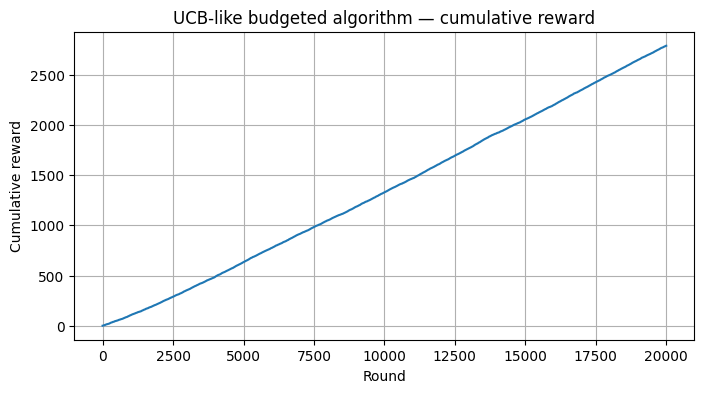

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(results["cum_rewards"])
plt.xlabel("Round")
plt.ylabel("Cumulative reward")
plt.title("UCB-like budgeted algorithm — cumulative reward")
plt.grid(True)
plt.show()

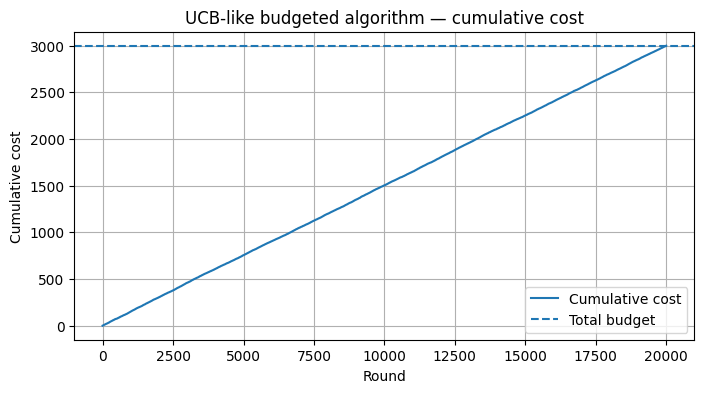

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(results["cum_costs"], label="Cumulative cost")
plt.axhline(total_budget, linestyle="--", label="Total budget")
plt.xlabel("Round")
plt.ylabel("Cumulative cost")
plt.title("UCB-like budgeted algorithm — cumulative cost")
plt.legend()
plt.grid(True)
plt.show()

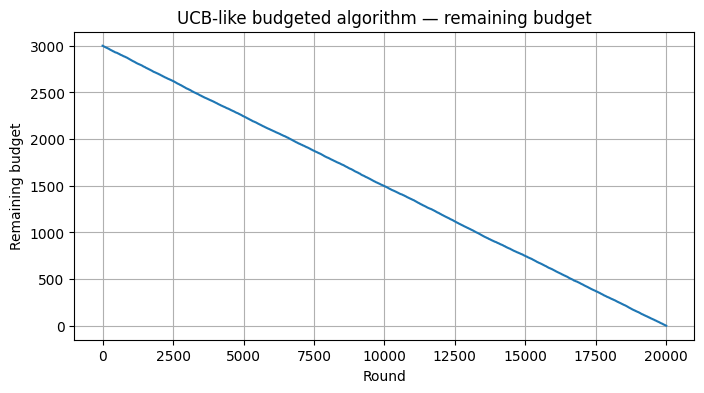

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(results["remaining_budgets"])
plt.xlabel("Round")
plt.ylabel("Remaining budget")
plt.title("UCB-like budgeted algorithm — remaining budget")
plt.grid(True)
plt.show()

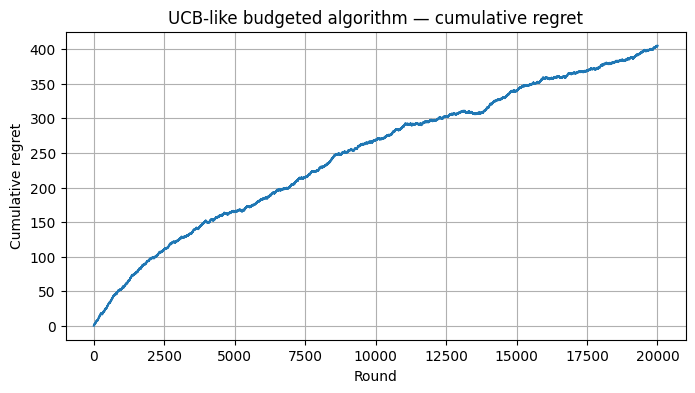

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(results["cum_regret"])
plt.xlabel("Round")
plt.ylabel("Cumulative regret")
plt.title("UCB-like budgeted algorithm — cumulative regret")
plt.grid(True)
plt.show()